In [1]:
!pip install pyspark


In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Attendance Analytics") \
    .getOrCreate()

In [3]:
from google.colab import files

uploaded = files.upload()


Saving employee_tasks.csv to employee_tasks.csv
Saving employee_attendance.csv to employee_attendance.csv


In [4]:
attendance_df = spark.read.csv(
    "employee_attendance.csv",
    header=True,
    inferSchema=True
)

attendance_df.show()

+-----------+-------------+----------+----------+-------+
|employee_id|employee_name|department|      date| status|
+-----------+-------------+----------+----------+-------+
|       E101|        Rahul|        IT|2026-06-01|Present|
|       E102|        Priya|        HR|2026-06-01|Present|
|       E103|         Amit|   Finance|2026-06-01| Absent|
|       E104|        Sneha|        IT|2026-06-01|Present|
|       E105|        Kiran|        HR|2026-06-01| Absent|
|       E106|        Megha|   Finance|2026-06-01|Present|
|       E107|        Arjun|        IT|2026-06-01|Present|
|       E108|         Neha|        HR|2026-06-01|Present|
|       E109|         Ravi|   Finance|2026-06-01|Present|
|       E110|       Anjali|        IT|2026-06-01| Absent|
|       E111|       Vikram|        HR|2026-06-01|Present|
|       E112|        Pooja|   Finance|2026-06-01|Present|
+-----------+-------------+----------+----------+-------+



In [5]:
tasks_df = spark.read.csv(
    "employee_tasks.csv",
    header=True,
    inferSchema=True
)

tasks_df.show()

+-----------+---------------+
|employee_id|tasks_completed|
+-----------+---------------+
|       E101|              8|
|       E102|              5|
|       E103|              2|
|       E104|              9|
|       E105|              1|
|       E106|              7|
|       E107|              6|
|       E108|              4|
|       E109|              8|
|       E110|              3|
|       E111|              5|
|       E112|              9|
+-----------+---------------+



In [6]:
attendance_df.printSchema()

tasks_df.printSchema()

root
 |-- employee_id: string (nullable = true)
 |-- employee_name: string (nullable = true)
 |-- department: string (nullable = true)
 |-- date: date (nullable = true)
 |-- status: string (nullable = true)

root
 |-- employee_id: string (nullable = true)
 |-- tasks_completed: integer (nullable = true)



In [7]:
attendance_df = attendance_df.dropna()

tasks_df = tasks_df.dropna()

In [8]:
final_df = attendance_df.join(
    tasks_df,
    on="employee_id",
    how="inner"
)

final_df.show()

+-----------+-------------+----------+----------+-------+---------------+
|employee_id|employee_name|department|      date| status|tasks_completed|
+-----------+-------------+----------+----------+-------+---------------+
|       E101|        Rahul|        IT|2026-06-01|Present|              8|
|       E102|        Priya|        HR|2026-06-01|Present|              5|
|       E103|         Amit|   Finance|2026-06-01| Absent|              2|
|       E104|        Sneha|        IT|2026-06-01|Present|              9|
|       E105|        Kiran|        HR|2026-06-01| Absent|              1|
|       E106|        Megha|   Finance|2026-06-01|Present|              7|
|       E107|        Arjun|        IT|2026-06-01|Present|              6|
|       E108|         Neha|        HR|2026-06-01|Present|              4|
|       E109|         Ravi|   Finance|2026-06-01|Present|              8|
|       E110|       Anjali|        IT|2026-06-01| Absent|              3|
|       E111|       Vikram|        HR|

In [9]:
from pyspark.sql.functions import *

department_kpi = final_df.groupBy("department").agg(

    count("*").alias("Total_Employees"),

    sum(when(col("status")=="Present",1).otherwise(0)).alias("Present"),

    sum(when(col("status")=="Absent",1).otherwise(0)).alias("Absent"),

    avg("tasks_completed").alias("Average_Tasks"),

    sum("tasks_completed").alias("Total_Tasks")

)

department_kpi.show()

+----------+---------------+-------+------+-------------+-----------+
|department|Total_Employees|Present|Absent|Average_Tasks|Total_Tasks|
+----------+---------------+-------+------+-------------+-----------+
|        HR|              4|      3|     1|         3.75|         15|
|   Finance|              4|      3|     1|          6.5|         26|
|        IT|              4|      3|     1|          6.5|         26|
+----------+---------------+-------+------+-------------+-----------+



In [10]:
department_kpi.toPandas().to_csv(
    "attendance_task_kpis.csv",
    index=False
)

In [11]:
files.download("attendance_task_kpis.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

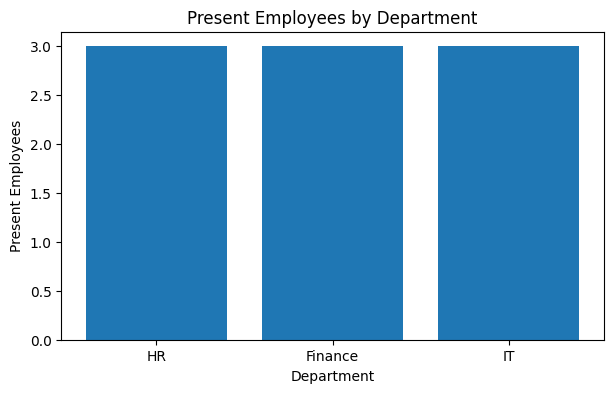

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("attendance_task_kpis.csv")

plt.figure(figsize=(7,4))

plt.bar(df["department"],df["Present"])

plt.title("Present Employees by Department")

plt.xlabel("Department")

plt.ylabel("Present Employees")

plt.show()

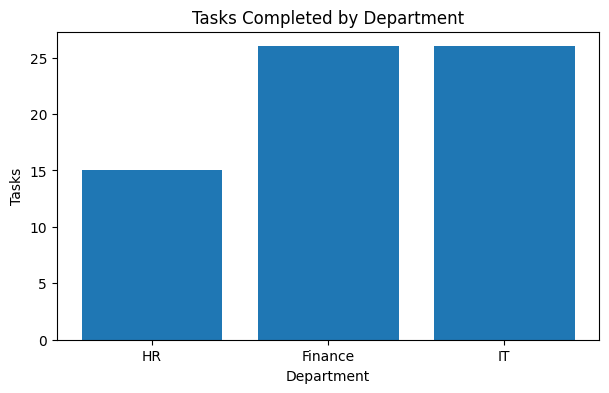

In [13]:
plt.figure(figsize=(7,4))

plt.bar(df["department"],df["Total_Tasks"])

plt.title("Tasks Completed by Department")

plt.xlabel("Department")

plt.ylabel("Tasks")

plt.show()